# CRM → Billing configuration prediction — Sprints 1 to 3

**Case Study I** (Moodle section 8608). Final, self-contained notebook: all code is in this
notebook; it reads only the competition CSVs and a few small data files produced earlier.

**Task.** A 4-Play telecom subscription is provisioned in several systems that drift out of
sync. From a customer's **CRM** configuration (745 binary columns) predict the correct
**Billing (BIL)** configuration (731 binary columns).
**Metric: Exact Match Ratio (EMR)**: a row counts only if all 731 bits are right.

| Milestone | Test EMR (`solution.csv`, diagnostic) |
|---|---|
| Sprint 2 champion | 95.04% |
| Sprint 3: suspected-corrupted training rows removed | 97.04% |
| **Sprint 3 final: + regularisation re-tuned on clean data** | **97.27%** |
| Public benchmark (reported) | ~98% |

**Storyline.**
1. Sprint 1: the data and what makes it hard.
2. A validation design that mirrors the test set.
3. Sprint 2: four modelling paradigms, and why per-label trees win.
4. Sprint 3: an audit reveals ~7–8% of training rows were corrupted by random injection; removing them is worth +2 test points.
5. SHAP explainability: the model learned the real product mapping.
6. Final fit and submission.
7. Threats to validity and conclusions.

Run time: about 10–15 minutes (two model fits on 731 labels).

## 0. Setup

In [1]:
import json
import os
import re
import time
import warnings

os.environ.setdefault('OMP_NUM_THREADS', '6')
warnings.filterwarnings('ignore', message='X does not have valid feature names')

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from joblib import Parallel, delayed
from scipy.stats import spearmanr
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit

DATA = '../data'
DERIVED = f'{DATA}/derived'
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.width', 160)

# Chart style: one light surface, recessive axes, blue / orange series.
SURFACE, INK, INK2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
BLUE, LIGHT_BLUE, ORANGE = '#2a78d6', '#9ec5f4', '#eb6834'
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 9, 'figure.facecolor': SURFACE})


def style(ax, grid='x'):
    ax.set_facecolor(SURFACE)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=8)
    ax.grid(axis=grid, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)

## 1. Load the data

Every CRM/BIL column is binary, so both files are read with an explicit `uint8` dtype map.
Pandas' default `int64` would use ~8× the memory on files of hundreds of MB.

In [2]:
t0 = time.time()
header = pd.read_csv(f'{DATA}/train.csv', nrows=0).columns.tolist()
crm_cols = [c for c in header if c.startswith('CRM')]
bil_cols = [c for c in header if c.startswith('BIL')]
dtypes = {c: 'uint8' for c in crm_cols + bil_cols} | {'MSISDN': str}

train = pd.read_csv(f'{DATA}/train.csv', dtype=dtypes)
test = pd.read_csv(f'{DATA}/test.csv', dtype={k: v for k, v in dtypes.items() if k in set(crm_cols) | {'MSISDN'}})
X = train[crm_cols].to_numpy(np.uint8)
Y_raw = train[bil_cols].to_numpy(np.uint8)
X_test = test[crm_cols].to_numpy(np.uint8)
msisdn_test = test['MSISDN'].to_numpy()
del train

print(f'train: {X.shape[0]:,} rows x {X.shape[1]} CRM + {Y_raw.shape[1]} BIL columns | '
      f'test: {X_test.shape[0]:,} rows | loaded in {time.time() - t0:.0f}s')
print(f'all values binary: {max(X.max(), Y_raw.max(), X_test.max()) <= 1}')

train: 187,442 rows x 745 CRM + 731 BIL columns | test: 97,100 rows | loaded in 9s
all values binary: True


---
# Sprint 1 — Pre-processing and exploratory analysis

The full Sprint 1 work is in `notebooks/sprint1_preprocessing_v3.ipynb`. The facts that
shaped Sprints 2 and 3 are recomputed here.

In [3]:
pack_crm = np.array([c.endswith('_PACK') for c in crm_cols])
pack_bil = np.array([c.endswith('_PACK') for c in bil_cols])
print(f'CRM: {pack_crm.sum()} pack flags + {(~pack_crm).sum()} categorical one-hot columns')
print(f'BIL: {pack_bil.sum()} pack flags + {(~pack_bil).sum()} categorical one-hot columns')
print(f'active columns per customer: CRM {X.sum(1).mean():.1f}, BIL {Y_raw.sum(1).mean():.1f}')

prev = Y_raw.mean(0)
tiers = pd.cut(prev, [-1e-9, 0.001, 0.01, 0.1, 0.5, 1.0],
               labels=['< 0.1%', '0.1–1%', '1–10%', '10–50%', '≥ 50%'])
print('\nBIL columns by prevalence (share of customers who have the item):')
display(pd.Series(tiers).value_counts().sort_index().rename('BIL columns').to_frame().T)

CRM: 730 pack flags + 15 categorical one-hot columns
BIL: 717 pack flags + 14 categorical one-hot columns
active columns per customer: CRM 15.3, BIL 14.7



BIL columns by prevalence (share of customers who have the item):


,< 0.1%,0.1–1%,1–10%,10–50%,≥ 50%
BIL columns,10,607,82,23,9


**Very sparse and imbalanced.** A customer has ~15 of 731 billing items, and over 600 billing
columns are active in less than 1% of rows. Getting *every* bit right is hard.

In [4]:
def row_keys(A):
    # Exact identity of each 0/1 row as bytes (np.packbits): no hashing, no collisions.
    return [r.tobytes() for r in np.packbits(np.asarray(A, dtype=np.uint8), axis=1)]


def factorize_rows(A):
    codes, uniq = pd.factorize(pd.Series(row_keys(A)), sort=False)
    return codes.astype(np.int64), len(uniq)


groups, n_crm_cfg = factorize_rows(X)
bil_codes, n_bil_cfg = factorize_rows(Y_raw)
pairs = pd.DataFrame({'crm': groups, 'bil': bil_codes})
n_bil_per_crm = pairs.groupby('crm')['bil'].nunique()
train_keys = set(row_keys(X))
seen = sum(k in train_keys for k in row_keys(X_test))

print(f'distinct CRM configurations: {n_crm_cfg:,} | distinct BIL configurations: {n_bil_cfg:,}')
print(f'CRM configurations with more than one BIL configuration (provisioning errors): '
      f'{(n_bil_per_crm > 1).sum():,} ({(n_bil_per_crm > 1).mean():.2%})')
print(f'test rows whose CRM configuration appears in train: {seen} of {len(X_test):,} ({seen / len(X_test):.4%})')

distinct CRM configurations: 67,434 | distinct BIL configurations: 67,201
CRM configurations with more than one BIL configuration (provisioning errors): 617 (0.91%)
test rows whose CRM configuration appears in train: 6 of 97,100 (0.0062%)


Three facts drove everything afterwards:
- **Noise.** Identical CRM configurations sometimes map to different billing. These are the
  provisioning errors the brief warns about.
- **Lookup does not transfer.** Essentially no test configuration appears in train, so the
  model must *generalise*. A random row split would let validation rows be answered by
  memorising duplicates, which is why validation is grouped by configuration (next section).
- **Sprint 1 built two candidate pipelines.** Section 10 relabels ambiguous groups and
  collapses correlated CRM columns. Section 11 adds a variance filter, χ² feature selection
  and 45 SVD components. Both were tested in Sprint 2.

In [5]:
svd = pd.read_csv(f'{DERIVED}/svd_variance_explained_v2.csv')
k80 = int((svd.cumulative_variance_ratio >= 0.80).idxmax()) + 1
print(f'Section 11 SVD: {k80} components needed for 80% of the variance -> the CRM space has no '
      f'low-dimensional structure (first component alone: {svd.explained_variance_ratio.iloc[0]:.1%})')

Section 11 SVD: 45 components needed for 80% of the variance -> the CRM space has no low-dimensional structure (first component alone: 4.8%)


---
# Validation design (used in Sprints 2 and 3)

- **Grouped split.** `GroupShuffleSplit` on the exact CRM configuration (20% validation,
  seed 42; every choice is confirmed on a second split, seed 7). No configuration is on both
  sides, as in the real test set.
- **Consensus targets.** Each validation row is scored against the most frequent *complete*
  BIL configuration of its CRM configuration, so the model is not rewarded for reproducing
  provisioning noise.
- **`solution.csv` is never used to learn or select.** It appears only in the last section,
  as a diagnostic of the frozen model.

In [6]:
def consensus_targets(crm_codes, Y):
    # Modal full BIL configuration per CRM configuration (ties: first seen).
    codes, _ = factorize_rows(Y)
    p = pd.DataFrame({'crm': crm_codes, 'bil': codes, 'pos': np.arange(len(Y))})
    cnt = p.groupby(['crm', 'bil'], sort=False).agg(n=('pos', 'size'), first=('pos', 'min')).reset_index()
    modal = cnt.sort_values(['crm', 'n', 'first'], ascending=[True, False, True]).drop_duplicates('crm')
    src = modal.set_index('crm')['first'].reindex(crm_codes).to_numpy()
    return Y[src], codes != codes[src]


def grouped_holdout(groups, seed=42):
    return next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
                .split(np.zeros(len(groups)), groups=groups))


Y, noisy = consensus_targets(groups, Y_raw)
tr, va = grouped_holdout(groups)
print(f'training rows that differ from their configuration consensus: {noisy.sum():,} ({noisy.mean():.2%})')
print(f'train fold {len(tr):,} rows | validation fold {len(va):,} rows | configurations on both sides: '
      f'{len(set(groups[tr]) & set(groups[va]))}')

training rows that differ from their configuration consensus: 1,315 (0.70%)
train fold 151,057 rows | validation fold 36,385 rows | configurations on both sides: 0


---
# Sprint 2 — Modelling

All four paradigms from the brief were compared on the same split. They took hours to run,
so their results are read from the experiment log (`data/derived/sprint2_experiment_results.csv`,
written by the project's experiment scripts) rather than recomputed. The final model is
re-fitted live in the Sprint 3 sections.

In [7]:
res = pd.read_csv(f'{DERIVED}/sprint2_experiment_results.csv')
res['params'] = res['params'].map(json.loads)
res['seed'] = res['params'].map(lambda p: p.get('split_seed', 42))


def pick(exp_id, pipeline=None):
    r = res[res.exp_id == exp_id]
    return r[r.pipeline == pipeline].iloc[-1] if pipeline else r.iloc[-1]


rows = [
    ('Hamming k-NN (k=15) — copy neighbours\' billing', pick('E1-knn15', 'raw')),
    ('Label powerset — choose among observed configs', pick('E2-lp')),
    ('Binary relevance LightGBM — Section 10 pipeline as built', pick('E3b')),
    ('Binary relevance LightGBM — Section 11 pipeline (SVD) as built', pick('E3c')),
    ('Binary relevance, raw CRM, unique configs, weighted (bug)', pick('E3a')),
    ('Binary relevance, raw CRM, unique configs, unweighted', pick('E3a2')),
    ('Classifier chain (co-occurrence order)', pick('E4-cc30')),
    ('Binary relevance, regularised (Sprint 2 champion)', pick('E5-reg-mcs20-t0.5')),
]
display(pd.DataFrame([{'model': n, 'validation EMR': f"{r.emr:.2%}"} for n, r in rows]))

,model,validation EMR
0,Hamming k-NN (k=15) — copy neighbours' billing,51.98%
1,Label powerset — choose among observed configs,23.09%
2,Binary relevance LightGBM — Section 10 pipeline as built,50.58%
3,Binary relevance LightGBM — Section 11 pipeline (SVD) as built,12.80%
4,"Binary relevance, raw CRM, unique configs, weighted (bug)",58.66%
5,"Binary relevance, raw CRM, unique configs, unweighted",80.05%
6,Classifier chain (co-occurrence order),80.57%
7,"Binary relevance, regularised (Sprint 2 champion)",87.84%


What Sprint 2 established:
1. **Billing is close to additive per CRM pack.** A neighbour that differs by one CRM pack
   usually differs by one BIL bit. Neighbour copying fails; one model per BIL column learns
   the mapping.
2. **Label powerset is capped at ~23%**: unseen CRM configurations produce unseen BIL
   configurations.
3. **Neither Sprint 1 feature transformation helps.** On identical training rows, Section
   10's column collapsing costs ~6 points and Section 11's SVD components ~33. Raw columns
   are used from here on.
4. **How rows are weighted matters more than the model family.** Weighting unique
   configurations by multiplicity (up to 8,114×) made rare labels fire on ~5% of rows;
   removing the weights took the same model from 58.7% to 80.1%.
5. **Variance was the dominant error.** Stronger leaf regularisation gave the Sprint 2
   champion (87.84% validation, **95.04% test**).

In [8]:
pipes = [('raw 745 CRM columns', 'E3a2'), ('Section 10 features', 'E3d'), ('Section 11 features (+45 SVD)', 'E3e')]
display(pd.DataFrame([{'features (same training rows and labels)': n, 'validation EMR': f'{pick(e).emr:.2%}'}
                      for n, e in pipes]))

,features (same training rows and labels),validation EMR
0,raw 745 CRM columns,80.05%
1,Section 10 features,74.31%
2,Section 11 features (+45 SVD),47.42%


---
# Sprint 3 — Optimisation: why was validation so much worse than test?

The Sprint 2 champion scored **87.8% on validation but 95.0% on test**. Following the
professor's hints (PCA, one-hot encoding, hidden pre-processing problems), each column family
was audited. Full audit trail: `docs/sprint3/SPRINT3_DIAGNOSTIC_LOG.md`.

## Finding 1 — impossible one-hot categories exist only in train

`BUSINESS_LINE`, `SUBSCRIBER_TYPE` and `SUBSCRIBER_STATUS` are one-hot blocks: exactly one
value per customer. A "test-like" row has exactly one value per block and never the value
literally called `0`.

In [9]:
def test_like_mask(A):
    blocks = {}
    for i, c in enumerate(crm_cols):
        m = re.match(r'^CRM_(.+?)_ORIG_(.+)$', c)
        if m:
            blocks.setdefault(m.group(1), []).append((i, m.group(2)))
    ok = np.ones(len(A), bool)
    for items in blocks.values():
        ok &= A[:, [i for i, _ in items]].sum(1) == 1
        zero = [i for i, v in items if v == '0']
        if zero:
            ok &= A[:, zero].sum(1) == 0
    return ok


test_like = test_like_mask(X)
print(f'test-like rows: train {test_like.mean():.2%} | test {test_like_mask(X_test).mean():.4%}')

status = np.array([c.startswith('CRM_SUBSCRIBER_STATUS_ORIG_') for c in crm_cols])
names = np.array([c.split('_ORIG_')[1] for c in np.array(crm_cols)[status]])
multi = X[:, status].sum(1) >= 2
combos = pd.Series(['+'.join(names[X[i, status] == 1]) for i in np.flatnonzero(multi)]).value_counts()
print(f'\n{multi.sum():,} training customers have 2+ statuses at once; most common combinations:')
display(combos.head(8).rename('customers').to_frame().T)

test-like rows: train 98.48% | test 99.9990%

1,901 training customers have 2+ statuses at once; most common combinations:


,Active+Barring,Active+Block_1_Way,Active+Block_2_Way,Active+Pre_Deactivated,Active+Deactive,0+Active,Active+Suspend,Active+Idle
customers,142,141,136,129,129,127,127,121


A customer cannot be `Active` and `Barring` at the same time. `Active` is paired with
*every* other status at almost the same rate, including very rare statuses and the
missing-value `0`, although those statuses differ in natural frequency by up to 100×. A real
status history would not be this uniform. These errors look **injected at random**.

## Finding 2 — bursts of random rare products in ~8% of training rows

A CRM pack is "rare" if it appears in fewer than 0.2% of training rows.

471 rare CRM packs | rows with >= 3 of them: train 8.00%, test 0.55%
in those rows the 471 rare packs are used almost equally often: coefficient of variation 0.12; rank correlation with their natural frequency in test 0.23
rare packs per row — not test-like rows: 6.43 CRM / 6.27 BIL; test-like rows: 0.50 / 0.50


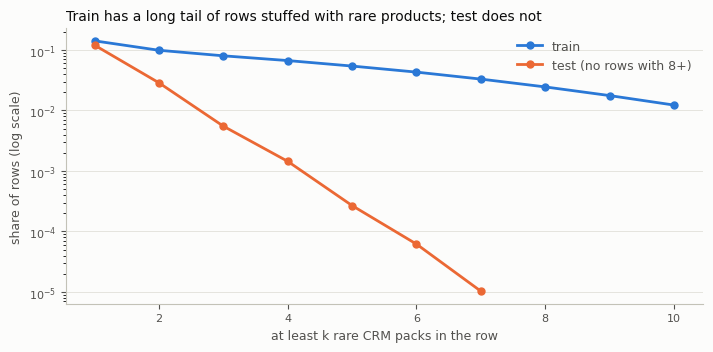

In [10]:
RARE_FREQ = 0.002
rare_crm = pack_crm & (X.mean(0) < RARE_FREQ)
rare_bil = pack_bil & (Y.mean(0) < RARE_FREQ)
rare_tr, rare_te = X[:, rare_crm].sum(1), X_test[:, rare_crm].sum(1)
rare_bil_tr = Y[:, rare_bil].sum(1)
print(f'{rare_crm.sum()} rare CRM packs | rows with >= 3 of them: train {np.mean(rare_tr >= 3):.2%}, '
      f'test {np.mean(rare_te >= 3):.2%}')

heavy = rare_tr >= 3
use = X[heavy][:, rare_crm].sum(0)
print(f'in those rows the {rare_crm.sum()} rare packs are used almost equally often: '
      f'coefficient of variation {use.std() / use.mean():.2f}; '
      f'rank correlation with their natural frequency in test {spearmanr(use, X_test[:, rare_crm].mean(0)).statistic:.2f}')
print(f'rare packs per row — not test-like rows: {rare_tr[~test_like].mean():.2f} CRM / '
      f'{rare_bil_tr[~test_like].mean():.2f} BIL; test-like rows: {rare_tr[test_like].mean():.2f} / '
      f'{rare_bil_tr[test_like].mean():.2f}')

ks = np.arange(1, 11)
share_te = np.array([np.mean(rare_te >= k) for k in ks])
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(ks, [np.mean(rare_tr >= k) for k in ks], color=BLUE, lw=2, marker='o', ms=5, label='train')
ax.plot(ks[share_te > 0], share_te[share_te > 0], color=ORANGE, lw=2, marker='o', ms=5,
        label=f'test (no rows with {ks[share_te > 0].max() + 1}+)')
ax.set_yscale('log')
style(ax, grid='y')
ax.set_xlabel('at least k rare CRM packs in the row', color=INK2)
ax.set_ylabel('share of rows (log scale)', color=INK2)
ax.set_title('Train has a long tail of rows stuffed with rare products; test does not', loc='left', color=INK, fontsize=10)
ax.legend(frameon=False, labelcolor=INK2)
plt.tight_layout()
plt.show()

Three signatures of random injection:
1. **Train has a long tail that test does not.** About 8% of training rows carry 3 or more
   rare packs, against 0.55% of test rows.
2. **The rare packs are used almost uniformly at random.** Real customers do not pick
   products uniformly; random injection does.
3. **The two sides are corrupted together.** Each injected CRM pack comes with an injected
   BIL pack, but the two are unrelated. The row then has the right number of products with
   the wrong identities, which is the "~9 false positives + ~9 false negatives" signature of
   Sprint 2's worst rows.

The impossible categories of Finding 1 are part of the same corruption. **Impact:** these
rows make validation look ~8 points worse than test, and they teach the model false links
for rare products.

## The fix, and how it was chosen

- **Clean-like validation metric.** Score only rows that are test-like with fewer than 3
  rare packs (uses CRM inputs only). It tracks the test score: Sprint 2 champion 95.9% vs
  95.0% on test.
- **Drop suspected-corrupted rows from training.** The cut-off k (drop rows with k or more
  rare packs, or not test-like) was swept and checked on a second split. The model itself
  is unchanged.

In [11]:
sweep = []
base = (res[res.exp_id.str.startswith('E7-rescore-E5-reg-mcs20')]
        .drop_duplicates('seed', keep='last').set_index('seed').emr_cleanlike)
sweep.append({'k': 'no drop (Sprint 2 champion)', 'seed 42': base.get(42), 'seed 7': base.get(7)})
for k in (2, 3, 4, 5, 6, 8):
    s42 = res[res.exp_id == f'E7-drop-k{k}'].emr_cleanlike
    s7 = res[res.exp_id == f'E7-drop-k{k}-s7'].emr_cleanlike
    sweep.append({'k': k, 'seed 42': s42.iloc[-1] if len(s42) else np.nan, 'seed 7': s7.iloc[-1] if len(s7) else np.nan})
display(pd.DataFrame(sweep).set_index('k').style.format('{:.2%}', na_rep='—'))

,seed 42,seed 7
k,,
no drop (Sprint 2 champion),95.93%,95.06%
2,95.45%,—
3,96.41%,—
4,96.57%,96.15%
5,96.50%,—
6,96.62%,95.80%
8,96.30%,—


Dropping too much (k=2) removes real customers; dropping too little (k=8) leaves corruption
in. k=4–6 form a plateau (within one standard error, ~0.1 points), and on the second split
k=4 wins clearly. **k=4 is selected** (6.9% of training rows dropped).

## Re-tuning on the cleaned data, and what did not help

The Sprint 2 regularisation (`min_child_samples=20`) was chosen while the corruption was
still in the data. Re-tuned on clean data:

In [12]:
def two_seeds(prefix):
    r = res[res.exp_id.isin([prefix, prefix + '-s7'])].drop_duplicates('exp_id', keep='last').set_index('seed').emr_cleanlike
    return r.get(42, np.nan), r.get(7, np.nan)


tune = [('min_child_samples 20 (after cleaning)', 'E7-drop-k4'), ('min_child_samples 10', 'E8-mcs10-l1'),
        ('min_child_samples 5  ← selected', 'E8-mcs5-l1'), ('min_child_samples 2', 'E8-mcs2-l1'),
        ('min_child_samples 5, reg_lambda 5', 'E8-mcs5-l5'), ('min_child_samples 5, reg_lambda 0', 'E8-mcs5-l0'),
        ('+ confident-learning cleaning', 'E10-cl-m1'), ('+ repair corrupted rows', 'E10-repair'),
        ('+ more capacity (200 trees / 31 leaves)', 'E10-cap')]
t = pd.DataFrame([dict(zip(['setting', 'seed 42', 'seed 7'], (n, *two_seeds(e)))) for n, e in tune]).set_index('setting')
t['mean'] = t.mean(1)
display(t.style.format('{:.2%}'))

,seed 42,seed 7,mean
setting,,,
min_child_samples 20 (after cleaning),96.57%,96.15%,96.36%
min_child_samples 10,96.78%,96.11%,96.45%
min_child_samples 5 ← selected,96.81%,96.33%,96.57%
min_child_samples 2,96.82%,96.36%,96.59%
"min_child_samples 5, reg_lambda 5",96.61%,96.25%,96.43%
"min_child_samples 5, reg_lambda 0",33.00%,26.29%,29.64%
+ confident-learning cleaning,96.59%,96.01%,96.30%
+ repair corrupted rows,96.60%,96.03%,96.31%
+ more capacity (200 trees / 31 leaves),96.87%,96.39%,96.63%


- **Smaller leaves help once the data is clean.** `min_child_samples=5` beats 20 on both
  splits. 2 ties with 5; by the one-standard-error rule the more regularised 5 is kept.
- **L2 regularisation is essential.** With `reg_lambda=0` one rare billing item fires on 27%
  of rows.
- **Tested and rejected** (each on both splits, all within noise or worse): cleaning by
  out-of-fold disagreement (it removes genuine rare products too), repairing corrupted rows
  (stripping rare packs also strips real ones), more capacity (+0.06, double the time), and
  a lower threshold for rare columns (+0.07 / +0.10, chosen on one split and checked on the
  other; not adopted).

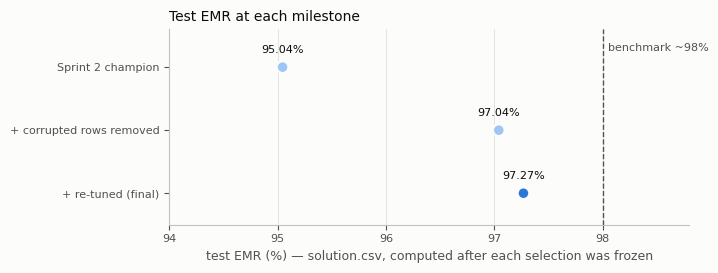

In [13]:
ext = {'EXT-solution': 'Sprint 2 champion', 'EXT-solution-drop-k4': '+ corrupted rows removed',
       'EXT-solution-drop-k4-mcs5': '+ re-tuned (final)'}
vals = [res[res.exp_id == k].emr.iloc[-1] for k in ext]
labels = list(ext.values())[::-1]
fig, ax = plt.subplots(figsize=(7.2, 2.8))
# Dots, not bars: the axis is zoomed to 94-99%, and bars would exaggerate the differences.
ax.scatter([v * 100 for v in vals][::-1], labels, s=70, color=[BLUE, LIGHT_BLUE, LIGHT_BLUE],
           edgecolors=SURFACE, linewidths=1.5, zorder=3)
ax.axvline(98, color=INK2, lw=1, ls='--')
ax.text(98.05, 2.25, 'benchmark ~98%', color=INK2, fontsize=8)
for y, v in enumerate(vals[::-1]):
    ax.text(v * 100, y + 0.22, f'{v:.2%}', ha='center', color=INK, fontsize=8)
ax.set_xlim(94, 98.8)
ax.set_ylim(-0.5, 2.6)
style(ax)
ax.set_xlabel('test EMR (%) — solution.csv, computed after each selection was frozen', color=INK2)
ax.set_title('Test EMR at each milestone', loc='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

---
# Final model — re-fitted live

Per-label LightGBM on the raw 745 CRM columns:
- trained on unique CRM configurations with consensus labels, after dropping
  suspected-corrupted rows (not test-like, or 4+ rare packs);
- 100 trees, 15 leaves, `min_child_samples=5`, `reg_lambda=1`, threshold 0.5;
- then the 42 deterministic "additive" rules from Sprint 1 (each BIL column = OR of its CRM
  triggers).

Fitted here on the seed-42 training fold, to reproduce the validation score and to explain it.

In [14]:
PARAMS = dict(n_estimators=100, num_leaves=15, learning_rate=0.1, min_child_samples=5,
              reg_lambda=1.0, verbose=-1)
with open(f'{DERIVED}/additive_rules_v2.json') as f:
    RULES = json.load(f)


def fit_one(Xf, y):
    if y.min() == y.max():
        return float(y[0])
    return lgb.LGBMClassifier(n_jobs=2, **PARAMS).fit(Xf, y)


def fit_models(Xu, Yu):
    Xf = Xu.astype(np.float32)
    return Parallel(n_jobs=8, backend='threading')(delayed(fit_one)(Xf, Yu[:, j]) for j in range(Yu.shape[1]))


def predict_proba(models, A):
    Af = A.astype(np.float32)
    one = lambda m: np.full(len(Af), m, np.float32) if isinstance(m, float) else m.predict_proba(Af)[:, 1]
    return np.column_stack(Parallel(n_jobs=8, backend='threading')(delayed(one)(m) for m in models))


def apply_rules(pred, A):
    out = pred.copy()
    ci, bi = {c: i for i, c in enumerate(crm_cols)}, {c: i for i, c in enumerate(bil_cols)}
    for b, trig in RULES.items():
        out[:, bi[b]] = A[:, [ci[t] for t in trig]].max(1)
    return out


def unique_configs(A, B):
    codes, _ = factorize_rows(A)
    _, first = np.unique(codes, return_index=True)
    return A[first], B[first]


def predict(models, A):
    P = predict_proba(models, A)
    return P, apply_rules((P >= 0.5).astype(np.uint8), A)


keep = tr[test_like[tr] & (rare_tr[tr] < 4)]
Xu, Yu = unique_configs(X[keep], Y[keep])
t0 = time.time()
models = fit_models(Xu, Yu)
P_val, pred_val = predict(models, X[va])
print(f'dropped {len(tr) - len(keep):,} suspected-corrupted training rows; '
      f'fitted 731 models on {len(Xu):,} unique configurations in {time.time() - t0:.0f}s')

dropped 10,476 suspected-corrupted training rows; fitted 731 models on 43,552 unique configurations in 156s


In [15]:
Yv = Y[va]
clean_like = test_like & (rare_tr < 3)
for name, m in [('all validation rows', np.ones(len(va), bool)), ('test-like rows', test_like[va]),
                ('clean-like rows (primary)', clean_like[va])]:
    emr = (pred_val[m] == Yv[m]).all(1).mean()
    print(f'{name:28s} {m.sum():6,} rows   EMR {emr:.2%}')

cl = clean_like[va]
yt, yp = Yv[cl], pred_val[cl]
active = yt.sum(0) > 0
report = pd.Series({
    'EMR': (yt == yp).all(1).mean(),
    'bit accuracy': (yt == yp).mean(),
    'F1 micro': f1_score(yt, yp, average='micro'),
    'F1 macro (columns with positives)': f1_score(yt[:, active], yp[:, active], average='macro', zero_division=0),
    'precision micro': precision_score(yt, yp, average='micro'),
    'recall micro': recall_score(yt, yp, average='micro'),
})
display(report.to_frame('clean-like validation').style.format('{:.4f}'))
cm = pd.DataFrame([[int(((yt == 1) & (yp == 1)).sum()), int(((yt == 1) & (yp == 0)).sum())],
                   [int(((yt == 0) & (yp == 1)).sum()), int(((yt == 0) & (yp == 0)).sum())]],
                  index=['actual 1', 'actual 0'], columns=['predicted 1', 'predicted 0'])
display(cm.style.format('{:,}'))
err = (yt != yp).sum(1)
r = rare_tr[va][cl]
print(f'EMR on clean-like rows with no rare pack: {np.mean(err[r == 0] == 0):.2%} | '
      f'with 1–2 rare packs ({np.mean(r > 0):.1%} of rows): {np.mean(err[r > 0] == 0):.2%}')

all validation rows          36,385 rows   EMR 88.65%
test-like rows               35,818 rows   EMR 90.05%
clean-like rows (primary)    33,261 rows   EMR 96.81%


,clean-like validation
EMR,0.9681
bit accuracy,0.9998
F1 micro,0.9958
F1 macro (columns with positives),0.5340
precision micro,0.9987
recall micro,0.9929


,predicted 1,predicted 0
actual 1,"474,417","3,369"
actual 0,612,"23,835,393"


EMR on clean-like rows with no rare pack: 99.18% | with 1–2 rare packs (7.1% of rows): 65.63%


- This reproduces the Sprint 3 champion's validation score.
- Errors are mostly **missed** billing items: false negatives far outnumber false positives.
- Almost all remaining errors sit in the few rows with 1–2 rare products. Rows without one
  are ~99% exact.

---
# Explainability (SHAP)

SHAP values come from LightGBM's built-in TreeSHAP (`pred_contrib=True`, identical to
`shap.TreeExplainer`), in log-odds, on clean-like **validation** rows.
- **Importance** of a CRM column for a BIL column = mean |SHAP| over the rows where that BIL
  item is billed (true or predicted). This answers "why does this item get billed?".
- **Expected driver** = the CRM column that co-occurs best with the BIL column in the
  cleaned training data. It is computed without the model, so agreement is a real check.

In [16]:
Xf, Yf = Xu.astype(np.float32), Yu.astype(np.float32)
inter = Xf.T @ Yf
cooc = np.minimum(inter / np.maximum(Xf.sum(0)[:, None], 1), inter / np.maximum(Yf.sum(0)[None, :], 1))
expected, expected_score = cooc.argmax(0), cooc.max(0)

rng = np.random.default_rng(0)
Xv = X[va].astype(np.float32)
cl_idx = np.flatnonzero(cl)
imp = np.zeros((len(bil_cols), len(crm_cols)), np.float32)
pos_rows = {}
t0 = time.time()
for j, m in enumerate(models):
    rows = cl_idx[(Yv[cl_idx, j] == 1) | (pred_val[cl_idx, j] == 1)]
    if len(rows) > 400:
        rows = rng.choice(rows, 400, replace=False)
    if len(rows) == 0:
        rows = rng.choice(cl_idx, 400, replace=False)
    pos_rows[j] = Xv[rows]
    if not isinstance(m, float):
        imp[j] = np.abs(m.booster_.predict(pos_rows[j], pred_contrib=True)[:, :-1]).mean(0)
print(f'SHAP for 731 models in {time.time() - t0:.0f}s')

top = imp.argmax(1)
conc = imp.max(1) / np.maximum(imp.sum(1), 1e-12)
tp_, fp_, fn_ = (((yt == 1) & (yp == 1)).sum(0), ((yt == 0) & (yp == 1)).sum(0), ((yt == 1) & (yp == 0)).sum(0))
f1_col = np.where(tp_ + fp_ + fn_ > 0, 2 * tp_ / np.maximum(2 * tp_ + fp_ + fn_, 1), np.nan)
in_top3 = np.array([expected[j] in np.argsort(-imp[j])[:3] for j in range(len(bil_cols))])
strong = expected_score >= 0.8
display(pd.DataFrame([
    {'BIL columns': 'with a clear expected driver (score >= 0.8)', 'count': strong.sum(),
     'top SHAP driver = expected': (top == expected)[strong].mean(), 'expected in SHAP top 3': in_top3[strong].mean()},
    {'BIL columns': 'without one', 'count': (~strong).sum(),
     'top SHAP driver = expected': (top == expected)[~strong].mean(), 'expected in SHAP top 3': in_top3[~strong].mean()},
]).set_index('BIL columns').style.format({'top SHAP driver = expected': '{:.1%}', 'expected in SHAP top 3': '{:.1%}'}))

SHAP for 731 models in 8s


,count,top SHAP driver = expected,expected in SHAP top 3
BIL columns,,,
with a clear expected driver (score >= 0.8),233,95.7%,99.1%
without one,498,46.4%,50.2%


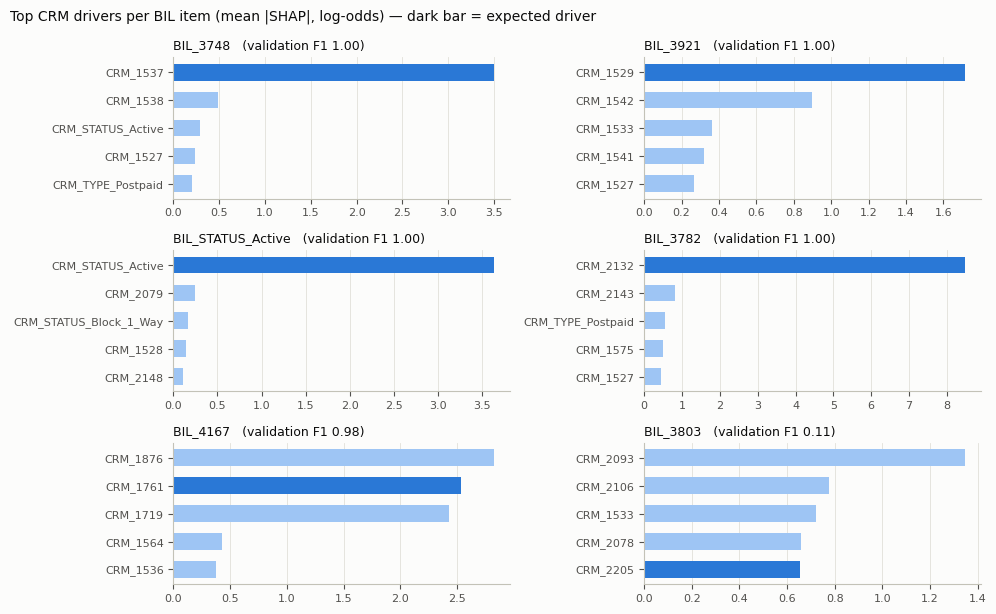

In [17]:
SELECTED = ['BIL_3748_PACK', 'BIL_3921_PACK', 'BIL_SUBSCRIBER_STATUS_ORIG_Active', 'BIL_3782_PACK',
            'BIL_4167_PACK', 'BIL_3803_PACK']
short = lambda c: c.replace('_PACK', '').replace('SUBSCRIBER_STATUS_ORIG_', 'STATUS_').replace('SUBSCRIBER_TYPE_ORIG_', 'TYPE_')
crm_arr = np.array(crm_cols)
fig, axes = plt.subplots(3, 2, figsize=(10, 6.2))
for ax, b in zip(axes.ravel(), SELECTED):
    j = bil_cols.index(b)
    order = np.argsort(-imp[j])[:5][::-1]
    ax.barh([short(crm_arr[f]) for f in order], imp[j, order],
            color=[BLUE if f == expected[j] else LIGHT_BLUE for f in order], height=0.6)
    style(ax)
    ax.set_title(f'{short(b)}   (validation F1 {f1_col[j]:.2f})', loc='left', color=INK, fontsize=9)
fig.suptitle('Top CRM drivers per BIL item (mean |SHAP|, log-odds) — dark bar = expected driver',
             x=0.01, ha='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

**Where a clear CRM → BIL link exists, the model uses exactly that link.** For example:
- `BIL_3748` ← `CRM_1537`;
- the BIL `Active` status ← the CRM `Active` status;
- the rare `BIL_3782` ← the rare `CRM_2132`.

`BIL_4167` is billed for any of three CRM packs (`1876`, `1761`, `1719`). That is the
many-to-one CRM → BIL mapping, and the model handles it. `BIL_3803` has no dominant cause,
and its F1 is low.

,columns,median_F1
band,,
≤ 0.3 (diffuse),299,0.00
0.3–0.5,116,0.67
0.5–0.7,150,0.95
> 0.7 (one clear driver),166,0.99


Spearman(concentration, F1) over 726 columns: +0.86


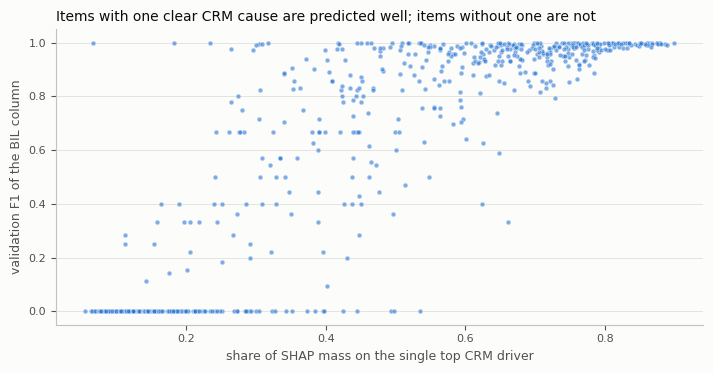

noise check: median SHAP share on rare CRM packs 1.1%; 119 columns lean > 50% on rare packs, and for 100% of them that rare pack is the column's own expected driver


In [18]:
ok = ~np.isnan(f1_col)
bands = pd.cut(conc, [0, 0.3, 0.5, 0.7, 1.0], labels=['≤ 0.3 (diffuse)', '0.3–0.5', '0.5–0.7', '> 0.7 (one clear driver)'])
summary = pd.DataFrame({'band': bands, 'f1': f1_col}).groupby('band', observed=True).agg(
    columns=('f1', 'size'), median_F1=('f1', 'median'))
display(summary.style.format({'median_F1': '{:.2f}'}))
print(f'Spearman(concentration, F1) over {ok.sum()} columns: {spearmanr(conc[ok], f1_col[ok]).statistic:+.2f}')

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.scatter(conc[ok], f1_col[ok], s=12, color=BLUE, alpha=0.6, edgecolors=SURFACE, linewidths=0.5)
style(ax, grid='y')
ax.set_xlabel('share of SHAP mass on the single top CRM driver', color=INK2)
ax.set_ylabel('validation F1 of the BIL column', color=INK2)
ax.set_title('Items with one clear CRM cause are predicted well; items without one are not',
             loc='left', color=INK, fontsize=10)
plt.tight_layout()
plt.show()

share_rare = imp[:, rare_crm].sum(1) / np.maximum(imp.sum(1), 1e-12)
hi = share_rare > 0.5
print(f'noise check: median SHAP share on rare CRM packs {np.median(share_rare):.1%}; '
      f'{hi.sum()} columns lean > 50% on rare packs, and for {np.mean(rare_crm[expected[hi]]):.0%} of them '
      f'that rare pack is the column\'s own expected driver')

- **The errors have an explanation.** How much of a column's explanation rests on its single
  top driver strongly predicts its F1. Billing items with no single CRM cause (many of them
  differ even between customers with *identical* CRM data) are not predictable from CRM,
  which is the floor that Sprint 3's further experiments could not move.
- **No sign of learning the injected noise.** Columns that lean on rare CRM packs lean on
  *their own* rare product, never on unrelated rare packs.

### A worked example of an error

In [19]:
err_rows = np.flatnonzero(cl & ((pred_val != Yv).sum(1) == 1))
cands = [(i, int(np.flatnonzero(pred_val[i] != Yv[i])[0])) for i in err_rows]
# Prefer a missed item whose expected driver (a rare product) is present; else any missed item.
example = next(((i, j) for i, j in cands if Yv[i, j] == 1 and Xv[i, expected[j]] == 1 and rare_crm[expected[j]]),
               next((i, j) for i, j in cands if Yv[i, j] == 1))
i, j = example
contrib = models[j].booster_.predict(Xv[i:i + 1], pred_contrib=True)[0]
present = np.flatnonzero(Xv[i] == 1)
order = present[np.argsort(-np.abs(contrib[present]))][:5]
print(f'{bil_cols[j]} is billed for this customer, but the model predicted p = {P_val[i, j]:.2f} (< 0.5)')
print(f'baseline log-odds {contrib[-1]:+.2f}; largest contributions from the CRM columns the customer has:')
for f in order:
    print(f'   {crm_cols[f]:34s} {contrib[f]:+6.2f}' + ('   <- expected driver (rare product)' if f == expected[j] else ''))

BIL_4139_PACK is billed for this customer, but the model predicted p = 0.23 (< 0.5)
baseline log-odds -8.44; largest contributions from the CRM columns the customer has:
   CRM_1727_PACK                       +7.60   <- expected driver (rare product)
   CRM_1570_PACK                       +0.63
   CRM_1608_PACK                       +0.55
   CRM_1525_PACK                       -0.50
   CRM_1606_PACK                       -0.46


The model found the **right** cause: the rare CRM product pushes strongly towards billing the
item. But with only a handful of clean training examples, the regularised evidence stops just
short of 0.5. This is why the remaining errors are mostly missed items on rare products.

---
# Final fit and submission

The frozen model is re-fitted on all of `train.csv` (minus suspected-corrupted rows) and
applied to `test.csv`.

In [20]:
keep_all = test_like & (rare_tr < 4)
Xa, Ya = unique_configs(X[keep_all], Y[keep_all])
t0 = time.time()
final_models = fit_models(Xa, Ya)
_, pred_test = predict(final_models, X_test)
print(f'dropped {(~keep_all).sum():,} rows ({(~keep_all).mean():.1%}); trained on {len(Xa):,} unique '
      f'configurations in {time.time() - t0:.0f}s')

sub = pd.DataFrame({'MSISDN': msisdn_test, 'Bill_Conf': [''.join(r) for r in pred_test.astype(str)]})
assert len(sub) == 97_100 and sub.notna().all().all() and sub['MSISDN'].is_unique
assert sub['Bill_Conf'].str.len().eq(731).all() and sub['Bill_Conf'].str.fullmatch('[01]+').all()
sub.to_csv(f'{DERIVED}/submission_sprint3_final.csv', index=False)
print('written data/derived/submission_sprint3_final.csv:', sub.shape)
sub.head(3)

dropped 13,131 rows (7.0%); trained on 54,387 unique configurations in 212s


written data/derived/submission_sprint3_final.csv: (97100, 2)


,MSISDN,Bill_Conf
0,db67b03cf9fb8ea96077cd34c7a28139,10000000000000000000000000000000000000000000000000000000000000000000000101100001010001...
1,2ac0d310d5cf1a96587af614d37b8b54,10000000001000000000000000000001000000000000000000000000000000000000000001100011000001...
2,a8f289fbd263794ac74059a18c1d10a5,11000001101111000000000000000000000100000000000000000000000000000000000000000000000000...


### External diagnostic — `solution.csv`

Computed **after** the model was frozen; never used for training or selection.

In [21]:
sol = pd.read_csv(f'{DATA}/solution.csv', dtype=str)
m = sub.merge(sol, on='MSISDN', suffixes=('', '_true'))
assert len(m) == len(sub)
to_bits = lambda s: np.array([np.frombuffer(x.encode(), np.uint8) - 48 for x in s])
Yt_test, Yp_test = to_bits(m['Bill_Conf_true']), to_bits(m['Bill_Conf'])
wrong = (Yt_test != Yp_test).sum(1)
print(f'test EMR {np.mean(wrong == 0):.2%} | rows 1 bit off {np.mean(wrong == 1):.2%} | '
      f'2+ bits off {np.mean(wrong >= 2):.2%} | F1 micro {f1_score(Yt_test, Yp_test, average="micro"):.4f}')

test EMR 97.27% | rows 1 bit off 2.12% | 2+ bits off 0.61% | F1 micro 0.9987


---
# Threats to validity

| Risk | Status |
|---|---|
| The 42 additive rules were derived in Sprint 1 from all of `train.csv` (including later validation rows). | Real leak, bounded. They add only +0.02 points to the final model's validation score; the test score is unaffected. |
| Sprint 1 SVD and χ² selection were fit on all of `train.csv`. | Not used by the final model (raw columns only). |
| Corruption filters designed by comparing train and test *inputs*. | Feature-only (no labels); disclosed. |
| Rows removed → survival bias? | Removed from **training** only; the test score uses all 97,100 test rows. |
| `solution.csv` scored at three milestones. | Always after selection; never used to choose. A diagnostic, not an untouched holdout. |
| Classifier chain with a single label order; no ensemble of chains. | Limitation; the chain tied plain per-label models. |

# Conclusions

1. **Sprint 1:** the data is extremely sparse and noisy, and test configurations are new.
   Validation is therefore grouped by configuration and scored against consensus targets.
2. **Sprint 2:** billing is close to additive per CRM pack. One LightGBM per BIL column,
   on raw columns, trained on unique configurations without weights, is the right model.
   Sprint 1's PCA/SVD and column collapsing hurt.
3. **Sprint 3:** an audit revealed ~7–8% of training rows corrupted by random injection
   (impossible categories, bursts of random rare products). Removing them from training and
   re-tuning regularisation took test EMR from **95.04% to 97.27%**.
4. **Explainability:** the model relies on the real CRM → BIL links (96–99% agreement
   with an independent check). Its errors are on items with no clear CRM cause, and it does
   not exploit the injected noise.
5. **Remaining gap to ~98%:** rows with 1–2 rare products, where the right cause is found but
   evidence is thin, plus items not predictable from CRM data.